# Bayesian - Gaussian random walk
### Attitudinal aggregation - 2028 Election

## Python set-up

In [1]:
"""Setup and imports."""

import sys

import matplotlib.pyplot as plt
import mgplot as mg
import numpy as np
import pandas as pd

# Add pymc tools to path
sys.path.insert(0, "pymc")

from bayes_tools import (
    check_residuals,
    draw_samples,
    grw_model,
    prepare_data_for_analysis,
)
from common import MIDDLE_DATE
from extraction import get_vector_var
from plot_house_effects import plot_house_effects_bar
from plot_posterior_timeseries import plot_posterior_timeseries
from plot_posteriors_bar import plot_posteriors_bar
from polling_data_etl import load_polling_data

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

SHOW = True
RFOOTER = "marktheballot.blogspot.com"
LFOOTER = "Australia. Polling data sourced from Wikipedia. "

In [2]:
# Set up plotting directory
mg.set_chart_dir("../charts/bayesian-attitudinal/")
mg.clear_chart_dir()

## Configuration

Leadership eras, transition dates, and helper functions.

In [3]:
# Configuration
MIN_POLLS = 3  # Lower threshold for attitudinal (fewer polls available)

# --- Leadership eras ---
# Each era defines a leader, their party, date range, and plot colors.
# To add a new leader (e.g. a third Coalition leader or second Labor leader),
# just append a new entry. The code handles any number of eras per party.
from dataclasses import dataclass


@dataclass
class LeaderEra:
    """A leadership era for attitudinal polling."""

    leader: str  # Leader surname (matches CSV column naming)
    party: str  # "Labor" or "Coalition"
    start: str | None  # ISO date string or None (from beginning of data)
    end: str | None  # ISO date string or None (to end of data)
    ppm_palette: str  # Palette for preferred PM chart
    ppm_color: str  # Color for preferred PM comparison chart


LEADER_ERAS = [
    LeaderEra(
        leader="Albanese",
        party="Labor",
        start=None,
        end=None,
        ppm_palette="Reds",
        ppm_color="#dd0000",
    ),
    LeaderEra(
        leader="Ley",
        party="Coalition",
        start=None,
        end="2026-02-13",
        ppm_palette="Blues",
        ppm_color="#0000dd",
    ),
    LeaderEra(
        leader="Taylor",
        party="Coalition",
        start="2026-02-13",
        end=None,
        ppm_palette="Purples",
        ppm_color="#6600cc",
    ),
]

# Satisfaction palette sequences — cycled per era within a party.
# Each entry is a different hue family for clear visual distinction.
SAT_PALETTES = ["Greens", "BuPu", "YlOrBr"]
DIS_PALETTES = ["Oranges", "RdPu", "BuGn"]

# Build per-era satisfaction palette lookup (based on position within party)
_party_era_count: dict[str, int] = {}
SAT_PALETTE_MAP: dict[str, tuple[str, str]] = {}  # leader -> (sat_palette, dis_palette)
for _era in LEADER_ERAS:
    _idx = _party_era_count.get(_era.party, 0)
    SAT_PALETTE_MAP[_era.leader] = (
        SAT_PALETTES[_idx % len(SAT_PALETTES)],
        DIS_PALETTES[_idx % len(DIS_PALETTES)],
    )
    _party_era_count[_era.party] = _idx + 1

# Transition dates for vertical marker lines (leader changes)
TRANSITIONS = [
    ("2026-02-13", "Taylor replaces Ley"),
]


def columns_for_era(era: LeaderEra) -> dict[str, str]:
    """Return mapping of measure_type -> column name for a leader era."""
    return {
        "ppm": f"Preferred prime minister {era.leader}",
        "satisfied": f"{era.leader} Satisfied",
        "dissatisfied": f"{era.leader} Dissatisfied",
    }


def palette_for(era: LeaderEra, measure_type: str) -> str:
    """Get the palette for an era and measure type."""
    if measure_type == "ppm":
        return era.ppm_palette
    sat_pal, dis_pal = SAT_PALETTE_MAP[era.leader]
    return sat_pal if measure_type == "satisfied" else dis_pal


def filter_df_to_era(df: pd.DataFrame, era: LeaderEra) -> pd.DataFrame:
    """Filter dataframe to rows within a leader's era."""
    mask = pd.Series(True, index=df.index)
    if era.start is not None:
        mask &= df[MIDDLE_DATE] >= pd.Timestamp(era.start)
    if era.end is not None:
        mask &= df[MIDDLE_DATE] < pd.Timestamp(era.end)
    return df[mask].copy()


def _add_transition_lines(ax: plt.Axes) -> None:
    """Add vertical dotted lines at leadership transition dates."""
    for date_str, label in TRANSITIONS:
        period = pd.Period(date_str, freq="D")
        ax.axvline(
            period.ordinal,
            color="grey",
            linestyle=":",
            linewidth=1.5,
            zorder=3,
            label=label,
        )

## Load Polling Data

Load the most recent attitudinal polling data using the ETL module.

In [4]:
# Load attitudinal data
df_raw = load_polling_data("preferred_pm")
print(f"\nLoaded {len(df_raw)} polls")
print(f"\nColumns: {list(df_raw.columns)}")

Using today's preferred_pm data file: ../poll-data/preferred_pm_next_2026-09-23.csv

Loaded 142 polls

Columns: ['Date', 'Brand', 'Sample size', 'Preferred prime minister Albanese', 'Preferred prime minister Taylor', 'Preferred prime minister Hanson', 'Preferred prime minister Unsure', 'Lead', 'Preferred prime minister Ley', 'Albanese Satisfied', 'Albanese Dissatisfied', 'Albanese Net', 'Taylor Satisfied', 'Taylor Dissatisfied', 'Taylor Net', 'Waters Satisfied', 'Waters Dissatisfied', 'Waters Net', 'Hanson Satisfied', 'Hanson Dissatisfied', 'Hanson Net', 'Ley Satisfied', 'Ley Dissatisfied', 'Ley Net', 'parsed_date']


In [5]:
# Display the raw data
df_raw.head(10)

,Date,Brand,Sample size,Preferred prime minister Albanese,Preferred prime minister Taylor,Preferred prime minister Hanson,Preferred prime minister Unsure,Lead,Preferred prime minister Ley,Albanese Satisfied,Albanese Dissatisfied,Albanese Net,Taylor Satisfied,Taylor Dissatisfied,Taylor Net,Waters Satisfied,Waters Dissatisfied,Waters Net,Hanson Satisfied,Hanson Dissatisfied,Hanson Net,Ley Satisfied,Ley Dissatisfied,Ley Net,parsed_date
parsed_date,,,,,,,,,,,,,,,,,,,,,,,,,
2026-09-12,10–14 Sept 2026,DemosAU,1583,45.0,NaN,33.0,22.0,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-12
2026-09-12,10–14 Sept 2026,DemosAU,1583,36.0,21.0,25.0,18.0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-12
2025-08-12,11–14 Aug 2025,Newspoll,1264,51.0,NaN,NaN,18.0,20,31.0,49.0,46.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,44.0,-9.0,2025-08-12
2026-01-14,12–16 Jan 2026,Newspoll,1224,51.0,31.0,NaN,18.0,20,NaN,42.0,53.0,-11.0,28.0,56.0,-28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-14
2026-01-14,12–16 Jan 2026,Resolve,1800,33.0,29.0,NaN,38.0,4,NaN,35.0,56.0,-21.0,35.0,42.0,-7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-14
2026-05-15,12–19 May 2026,YouGov,1504,41.0,38.0,NaN,21.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-15
2026-05-15,12–19 May 2026,YouGov,1504,50.0,NaN,38.0,12.0,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-15
2026-05-15,12–19 May 2026,YouGov,1504,NaN,NaN,NaN,NaN,NaN,NaN,37.0,56.0,-19.0,36.0,42.0,-6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-15
2026-04-14,13–16 Apr 2026,Newspoll,1235,NaN,NaN,NaN,NaN,NaN,NaN,40.0,57.0,-17.0,33.0,46.0,-13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-14


## Data Preparation

Prepare the data for Bayesian analysis - ensure correct column names and create derived columns.

In [6]:
# Data preparation
df = df_raw.copy()

# Rename parsed_date to Mean Date for compatibility with bayes_tools
if "parsed_date" in df.columns and MIDDLE_DATE not in df.columns:
    df[MIDDLE_DATE] = pd.to_datetime(df["parsed_date"])

# Drop annotation/marker rows (non-numeric Brand values that are very long)
marker_mask = df["Brand"].str.len() > 50
if marker_mask.any():
    print(f"Dropped {marker_mask.sum()} annotation row(s)")
    df = df[~marker_mask].copy()

# --- Identify 3-way PPM rows (for filtering at point of use) ---
# These rows have a third candidate (e.g. Hanson) and should be excluded
# from PPM analysis, but their satisfaction data is still valid.
# Stored as a column so it survives index changes and filtering.
third_party_cols = [
    c
    for c in df.columns
    if c.startswith("Preferred prime minister")
    and not any(
        c.endswith(suffix)
        for suffix in ["Albanese", "Unsure", "Don't know"]
        + [era.leader for era in LEADER_ERAS if era.party == "Coalition"]
    )
]
for col in third_party_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["_ppm_3way"] = (
    df[third_party_cols].notna().any(axis=1) if third_party_cols else False
)
print(
    f"Identified {df['_ppm_3way'].sum()} non-2-way PPM rows (excluded from PPM analysis only)"
)

# --- Coerce all numeric columns across all eras ---
numeric_cols = []
for era in LEADER_ERAS:
    for col in columns_for_era(era).values():
        if col not in numeric_cols:
            numeric_cols.append(col)
    dk_col = f"{era.leader} Don't know"
    if dk_col not in numeric_cols:
        numeric_cols.append(dk_col)
ppm_dk = "Preferred prime minister Don't know"
if ppm_dk not in numeric_cols:
    numeric_cols.append(ppm_dk)

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Prepared {len(df)} polls")
df.head()

Identified 39 non-2-way PPM rows (excluded from PPM analysis only)
Prepared 142 polls


,Date,Brand,Sample size,Preferred prime minister Albanese,Preferred prime minister Taylor,Preferred prime minister Hanson,Preferred prime minister Unsure,Lead,Preferred prime minister Ley,Albanese Satisfied,Albanese Dissatisfied,Albanese Net,Taylor Satisfied,Taylor Dissatisfied,Taylor Net,Waters Satisfied,Waters Dissatisfied,Waters Net,Hanson Satisfied,Hanson Dissatisfied,Hanson Net,Ley Satisfied,Ley Dissatisfied,Ley Net,parsed_date,Mean Date,_ppm_3way
parsed_date,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-09-12,10–14 Sept 2026,DemosAU,1583,45.0,NaN,33.0,22.0,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-12,2026-09-12,True
2026-09-12,10–14 Sept 2026,DemosAU,1583,36.0,21.0,25.0,18.0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-12,2026-09-12,True
2025-08-12,11–14 Aug 2025,Newspoll,1264,51.0,NaN,NaN,18.0,20,31.0,49.0,46.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,44.0,-9.0,2025-08-12,2025-08-12,False
2026-01-14,12–16 Jan 2026,Newspoll,1224,51.0,31.0,NaN,18.0,20,NaN,42.0,53.0,-11.0,28.0,56.0,-28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-14,2026-01-14,False
2026-01-14,12–16 Jan 2026,Resolve,1800,33.0,29.0,NaN,38.0,4,NaN,35.0,56.0,-21.0,35.0,42.0,-7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-14,2026-01-14,False


In [7]:
# Check pollsters (Brand) in the data
print("Pollsters in data:")
print(df["Brand"].value_counts())

Pollsters in data:
Brand
YouGov              36
Newspoll            33
Resolve             17
DemosAU             15
RedBridge/Accent    15
Essential           13
Fox & Hedgehog       4
Spectre Strategy     3
Morning Consult      3
Freshwater           2
Wolf & Smith         1
Name: count, dtype: int64


In [8]:
# Date range
print(f"Date range: {df[MIDDLE_DATE].min()} to {df[MIDDLE_DATE].max()}")
print(f"Number of days: {(df[MIDDLE_DATE].max() - df[MIDDLE_DATE].min()).days}")

Date range: 2025-05-05 00:00:00 to 2026-09-18 00:00:00
Number of days: 501


## Data Exploration

In [9]:
# Summary statistics
available_cols = [c for c in numeric_cols if c in df.columns]
df[available_cols].describe()

,Preferred prime minister Albanese,Albanese Satisfied,Albanese Dissatisfied,Preferred prime minister Ley,Ley Satisfied,Ley Dissatisfied,Preferred prime minister Taylor,Taylor Satisfied,Taylor Dissatisfied
count,101.000000,82.000000,82.000000,20.000000,20.000000,20.000000,62.000000,57.000000,57.000000
mean,43.188119,38.792683,50.731707,26.400000,31.600000,40.700000,29.016129,31.368421,41.035088
std,6.591984,6.554120,7.043163,6.029751,7.315449,8.066174,9.162454,7.011805,10.532204
min,29.000000,22.000000,33.000000,10.000000,13.000000,29.000000,9.000000,10.000000,17.000000
25%,39.000000,35.000000,46.000000,25.750000,31.000000,34.750000,22.000000,28.000000,33.000000
50%,44.000000,38.000000,51.500000,27.000000,33.000000,40.500000,32.000000,33.000000,43.000000
75%,48.000000,42.750000,57.000000,30.250000,35.250000,44.000000,37.000000,36.000000,49.000000
max,57.000000,57.000000,62.000000,35.000000,41.000000,58.000000,41.000000,44.000000,62.000000


## GRW Model Function

In [10]:
def run_grw_for_column(
    df: pd.DataFrame,
    column: str,
    constraint: str = "zero_median",
    min_polls: int = 3,
    draws: int = 5000,
    tune: int = 1000,
    cores: int = 4,
    target_accept: float = 0.80,
    max_tree_depth: int = 12,
    innovation: float = 0.1,
    likelihood: str = "StudentT",
) -> dict:
    """Run GRW model for a single column and return results."""

    print(f"\n{'=' * 60}")
    print(f"Processing: {column}")
    print(f"{'=' * 60}")

    # Filter to rows with valid data for this column
    df_analysis = df[df[column].notna()].copy()

    # Get poll counts by pollster
    poll_counts = df_analysis["Brand"].value_counts()

    print(f"Polls: {len(df_analysis)}")
    print(f"Pollsters: {list(poll_counts.index)}")
    print(f"Constraint: {constraint}")

    # Check minimum data requirements
    if len(df_analysis) < 5:
        print(f"WARNING: Only {len(df_analysis)} polls - skipping (need at least 5)")
        return None

    # Prepare data
    if constraint == "zero_sum":
        he_sum_exclusions = poll_counts[poll_counts < min_polls].index.tolist()
        print(f"Excluded from sum-to-zero (n<{min_polls}): {he_sum_exclusions}")
        inputs = prepare_data_for_analysis(
            df_analysis,
            column=column,
            he_sum_exclusions=he_sum_exclusions,
        )
    else:
        inputs = prepare_data_for_analysis(
            df_analysis,
            column=column,
        )

    # Build and run model
    model = grw_model(
        inputs, innovation=innovation, likelihood=likelihood, constraint=constraint
    )
    idata, glitches = draw_samples(
        model,
        draws=draws,
        tune=tune,
        cores=cores,
        target_accept=target_accept,
        nuts_sampler="numpyro",
        nuts_sampler_kwargs={"max_tree_depth": max_tree_depth},
    )

    if glitches:
        print(f"WARNING: {glitches}")

    print(f"Completed: {column}")

    return {
        "inputs": inputs,
        "model": model,
        "idata": idata,
        "glitches": glitches,
        "constraint": constraint,
        "poll_counts": poll_counts.to_dict(),
    }

## Run GRW Model for All Attitudinal Columns

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Preferred prime minister Albanese
Polls: 62
Pollsters: ['Newspoll', 'YouGov', 'Resolve', 'Fox & Hedgehog', 'DemosAU', 'RedBridge/Accent', 'Freshwater', 'Spectre Strategy', 'Wolf & Smith']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 930
Maximum MCSE/sd ratio: 0.033
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (12): 0.01% (comparing to observed max)
Minimum BFMI: 0.97
Completed: Preferred prime minister Albanese


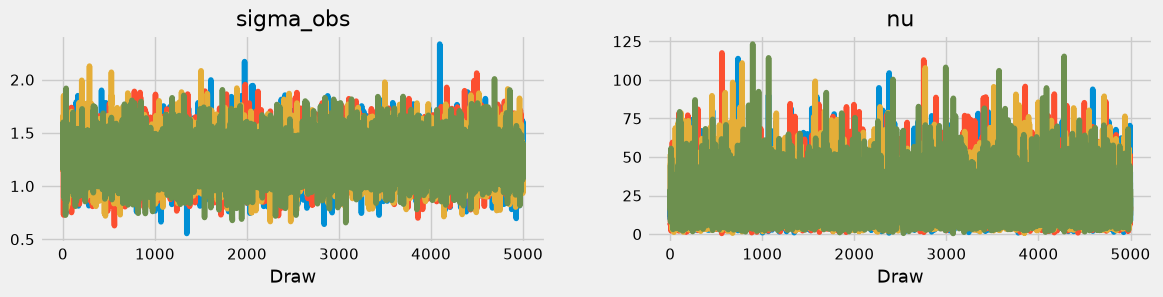

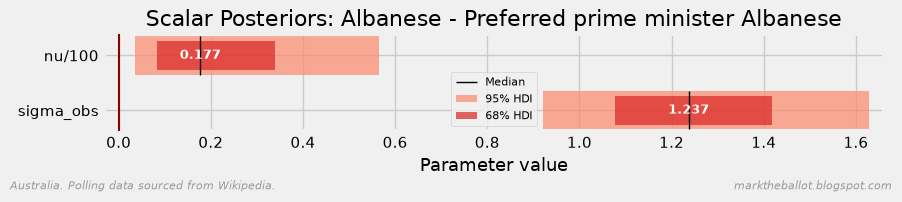

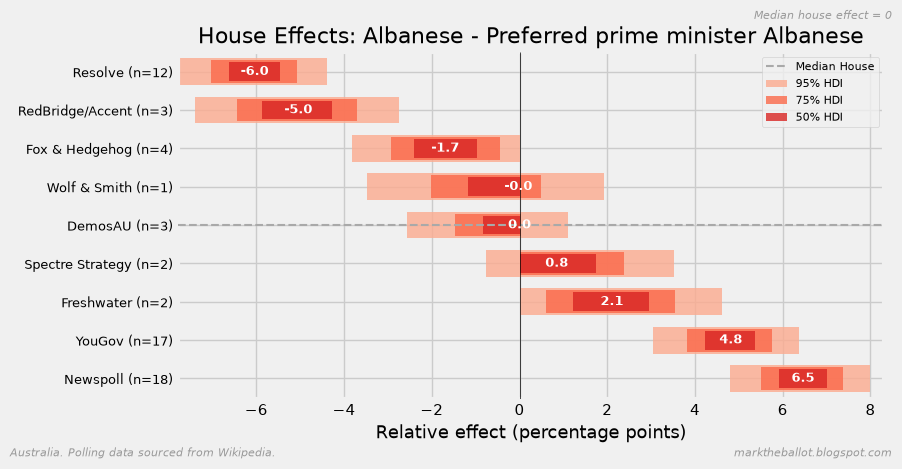


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.25
Minimum polls required: 5

Resolve (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heteroskedasticity p-value: 0.503 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: -0.77 (t-test p=0.377)

Newspoll (n=18)
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.883 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.36 (t-test p=0.561)

YouGov (n=17)
  Outside ±3σ: 0/17 (0.0%)
  Heteroskedasticity p-value: 0.281 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.21 (t-test p=0.603)

✓ No pollsters flagged for methodology concerns.


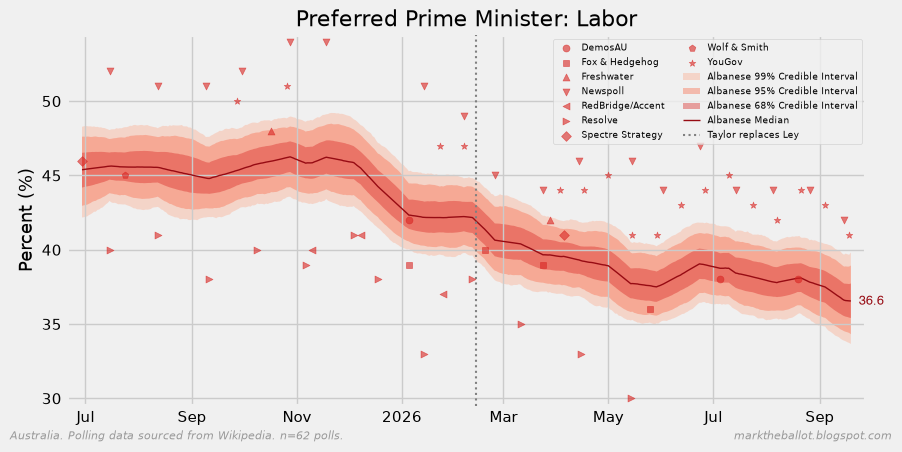

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Preferred prime minister Ley
Polls: 20
Pollsters: ['Resolve', 'Newspoll', 'YouGov', 'RedBridge/Accent', 'Freshwater', 'Wolf & Smith', 'Spectre Strategy']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 2400
Maximum MCSE/sd ratio: 0.021
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (10): 2.14% (comparing to observed max)
Minimum BFMI: 0.93
Completed: Preferred prime minister Ley


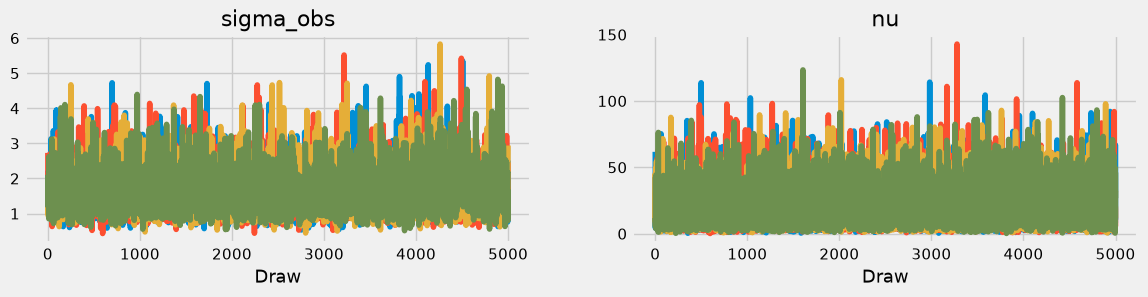

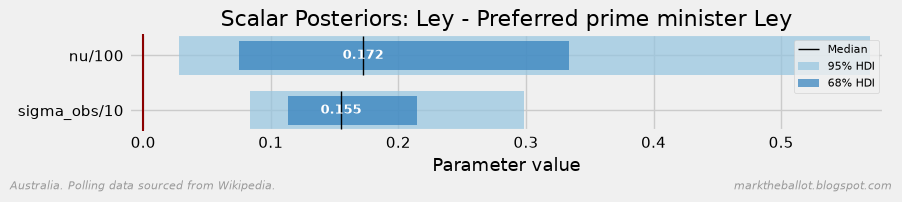

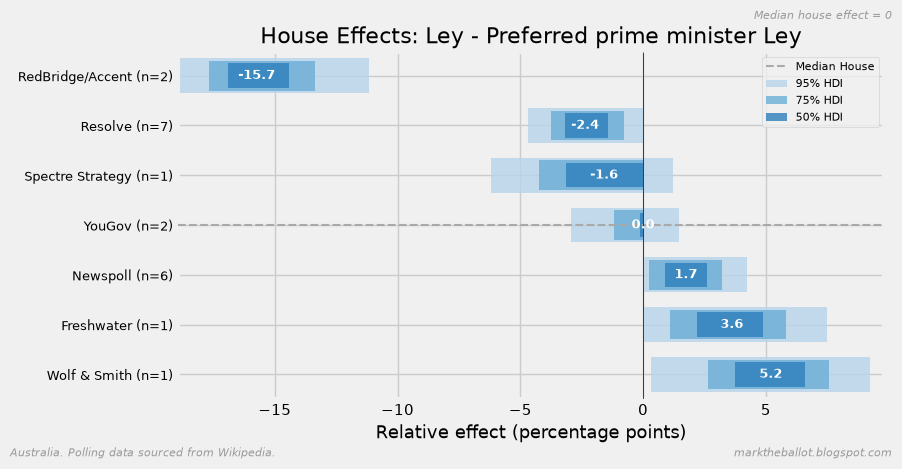

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.64
Minimum polls required: 5

Resolve (n=7)
  Outside ±3σ: 0/7 (0.0%)
  Heteroskedasticity p-value: 0.356 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +1.32 (t-test p=0.285)

Newspoll (n=6)
  Outside ±3σ: 0/6 (0.0%)
  Heteroskedasticity p-value: 0.393 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -1.56 (t-test p=0.133)

✓ No pollsters flagged for methodology concerns.

Processing: Preferred prime minister Taylor
Polls: 33
Pollsters: ['YouGov', 'Newspoll', 'Resolve', 'Fox & Hedgehog', 'DemosAU', 'Freshwater', 'Spectre Strategy']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 2500
Maximum MCSE/sd ratio: 0.021
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (11): 0.34% (comparing to observed max)
Minimum BFMI: 0.95
Completed: Preferred prime minister Taylor


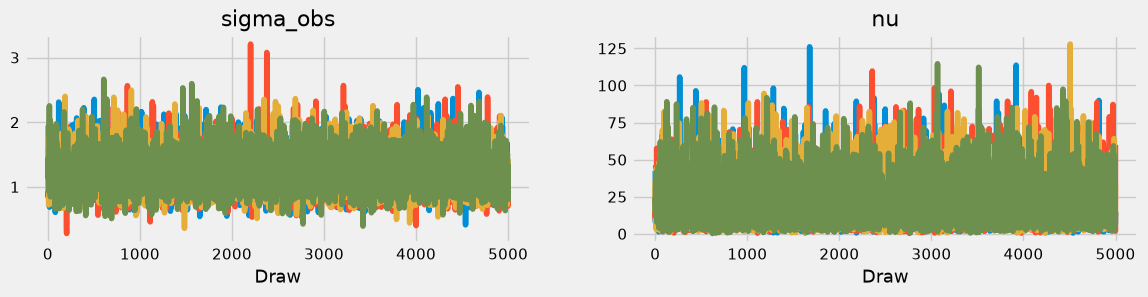

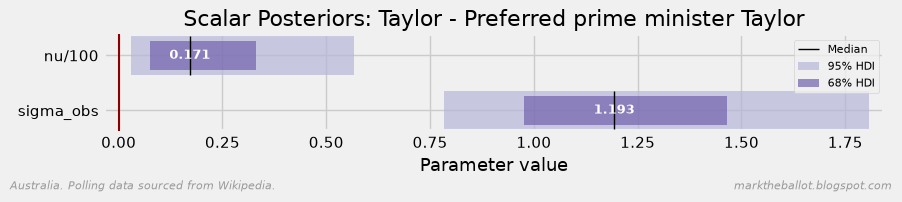

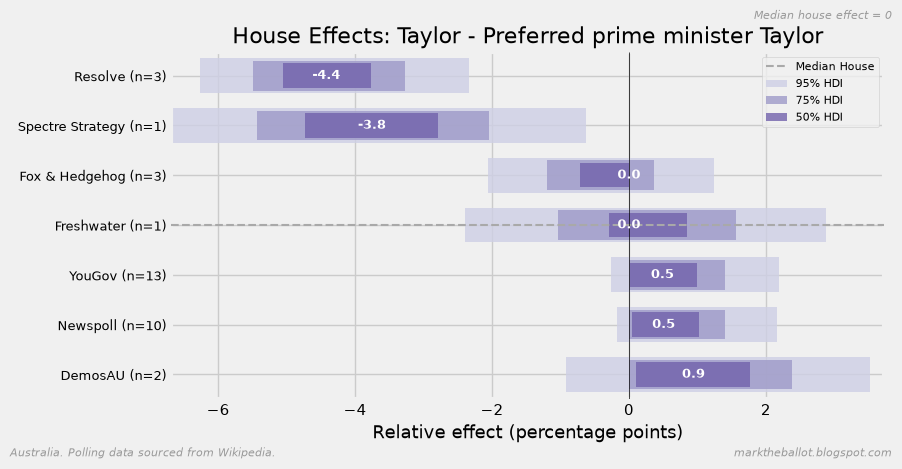


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.22
Minimum polls required: 5

Newspoll (n=10) ⚠️ SUSPECT
  Outside ±3σ: 0/10 (0.0%)
  Heteroskedasticity p-value: 0.046 (variance increasing)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: -0.05 (t-test p=0.953)

YouGov (n=13)
  Outside ±3σ: 0/13 (0.0%)
  Heteroskedasticity p-value: 0.986 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.51 (t-test p=0.421)

⚠️  1 pollster(s) flagged for potential methodology issues:
   - Newspoll


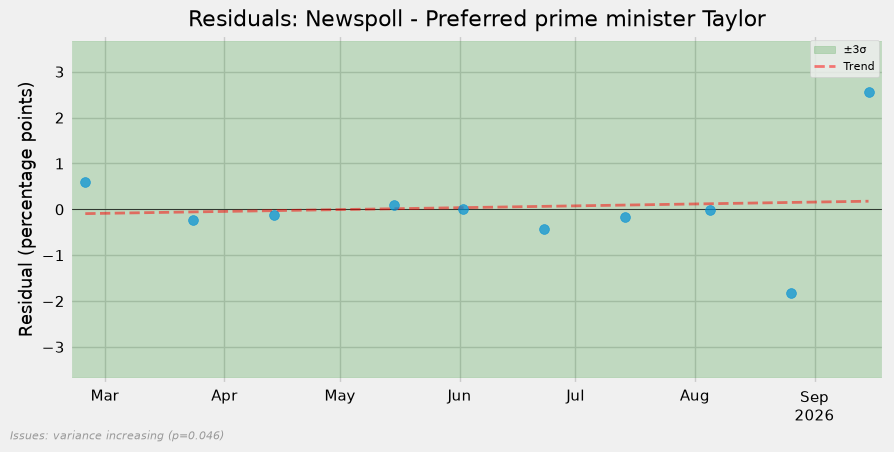

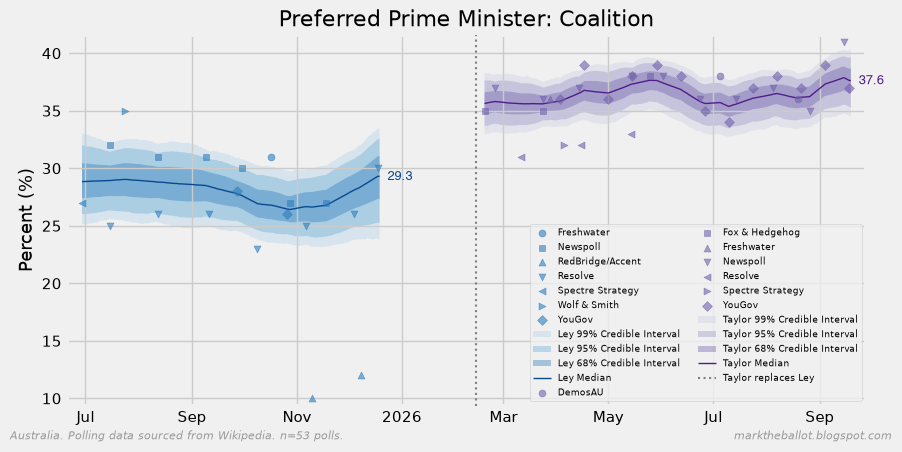

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Albanese Satisfied
Polls: 82
Pollsters: ['YouGov', 'Newspoll', 'Essential', 'Resolve', 'DemosAU', 'RedBridge/Accent', 'Fox & Hedgehog', 'Morning Consult', 'Freshwater']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 1100
Maximum MCSE/sd ratio: 0.035
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (11): 0.12% (comparing to observed max)
Minimum BFMI: 0.97
Completed: Albanese Satisfied


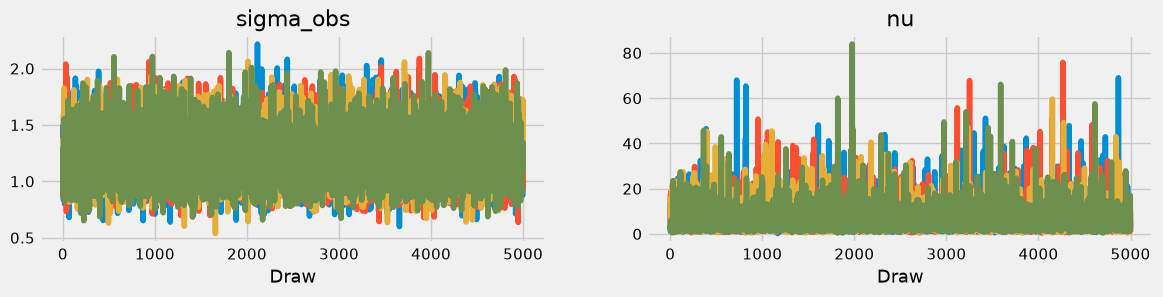

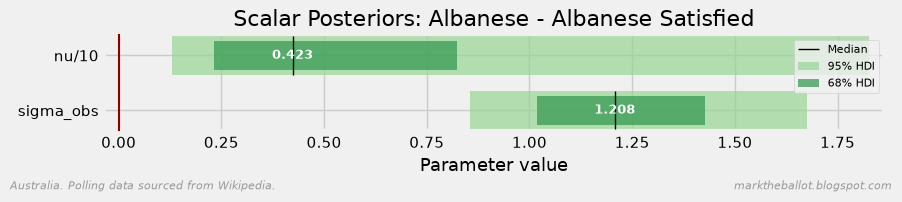

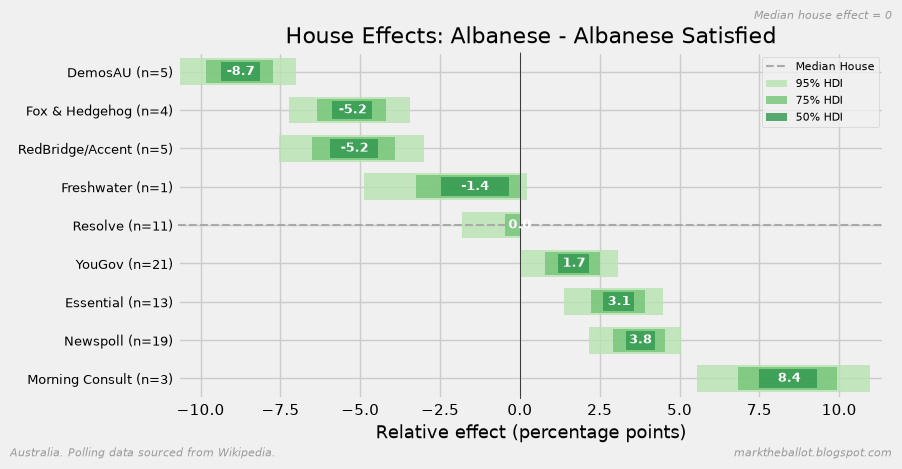


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.22
Minimum polls required: 5

Essential (n=13)
  Outside ±3σ: 0/13 (0.0%)
  Heteroskedasticity p-value: 0.641 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.45 (t-test p=0.505)

Resolve (n=11) ⚠️ SUSPECT
  Outside ±3σ: 1/11 (9.1%)
  Heteroskedasticity p-value: 0.956 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.43 (t-test p=0.729)

Newspoll (n=19)
  Outside ±3σ: 0/19 (0.0%)
  Heteroskedasticity p-value: 0.349 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.05 (t-test p=0.918)

RedBridge/Accent (n=5) ⚠️ SUSPECT
  Outside ±3σ: 1/5 (20.0%)
  Heteroskedasticity p-value: 0.519 (homoskedastic)
  Recent outliers: 1@3σ, 1@2σ (of 5)
  Mean shift: -3.46 (t-test p=0.410)

DemosAU (n=5)
  Outside ±3σ: 0/5 (0.0%)
  Heteroskedasticity p-value: 0.382 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +1.39 (t-test p=0.158)

YouGov (n=21)
  Outside ±3σ: 0/21

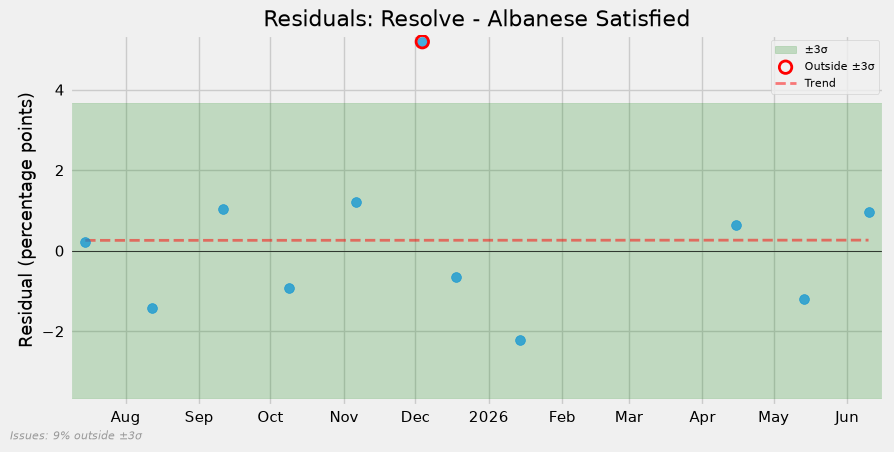

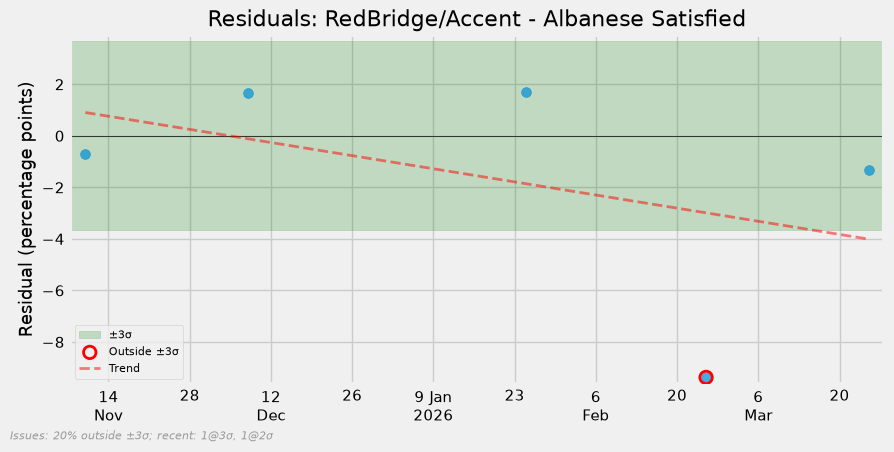

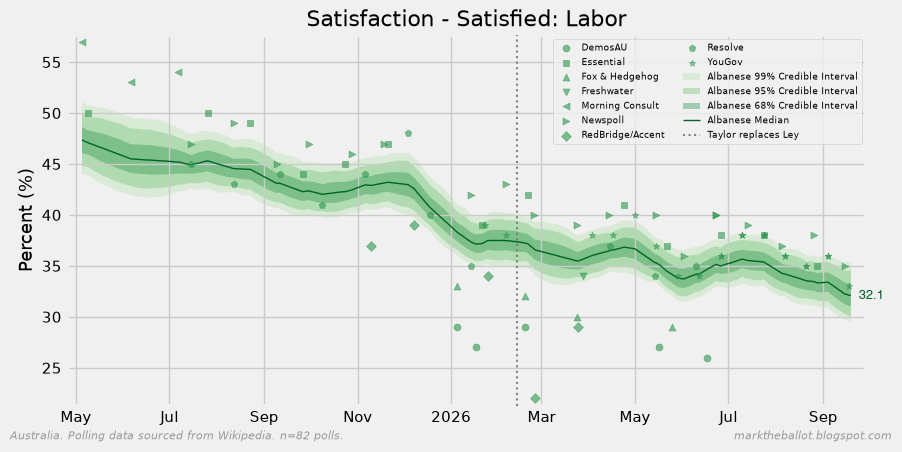

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Ley Satisfied
Polls: 20
Pollsters: ['Resolve', 'Newspoll', 'Essential', 'RedBridge/Accent']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 4900
Maximum MCSE/sd ratio: 0.015
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (10): 0.14% (comparing to observed max)
Minimum BFMI: 0.97
Completed: Ley Satisfied


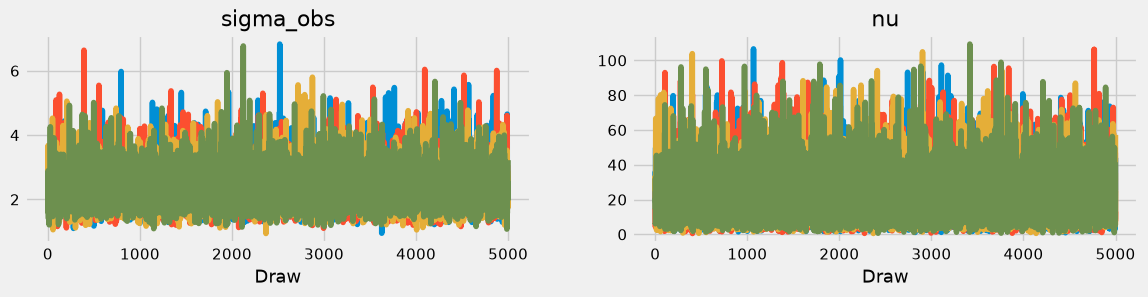

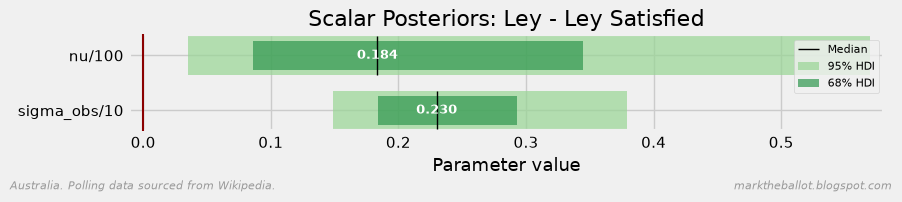

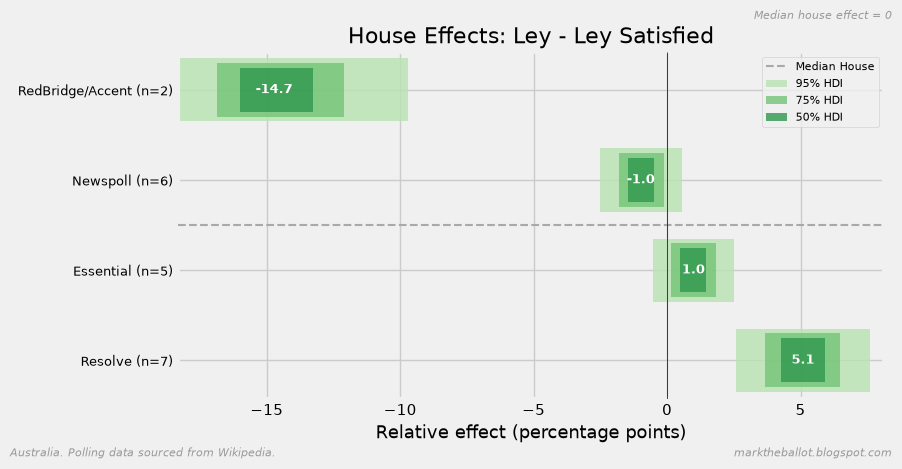

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



=== Residual Diagnostics by Pollster ===
Model sigma_obs: 2.39
Minimum polls required: 5

Resolve (n=7)
  Outside ±3σ: 0/7 (0.0%)
  Heteroskedasticity p-value: 0.499 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.30 (t-test p=0.882)

Newspoll (n=6)
  Outside ±3σ: 0/6 (0.0%)
  Heteroskedasticity p-value: 0.601 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -3.19 (t-test p=0.107)

Essential (n=5)
  Outside ±3σ: 0/5 (0.0%)
  Heteroskedasticity p-value: 0.496 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.93 (t-test p=0.545)

✓ No pollsters flagged for methodology concerns.

Processing: Taylor Satisfied
Polls: 47
Pollsters: ['YouGov', 'Newspoll', 'Essential', 'Resolve', 'DemosAU', 'Fox & Hedgehog', 'RedBridge/Accent', 'Freshwater']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 2100
Maximum MCSE/sd ratio: 0.022
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (10): 1.35% (comparing to observed max)
Minimum BFMI: 1.00
Completed: Taylor Satisfied


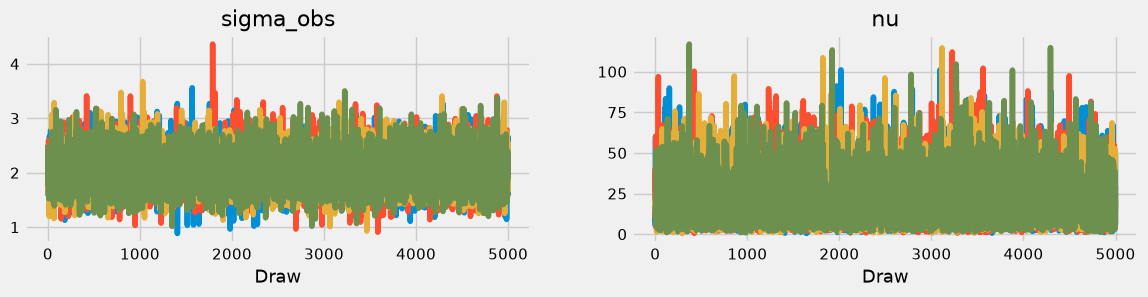

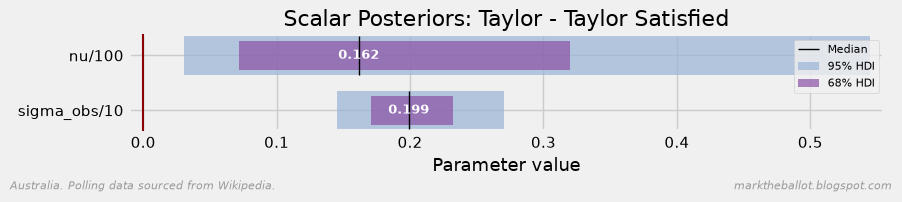

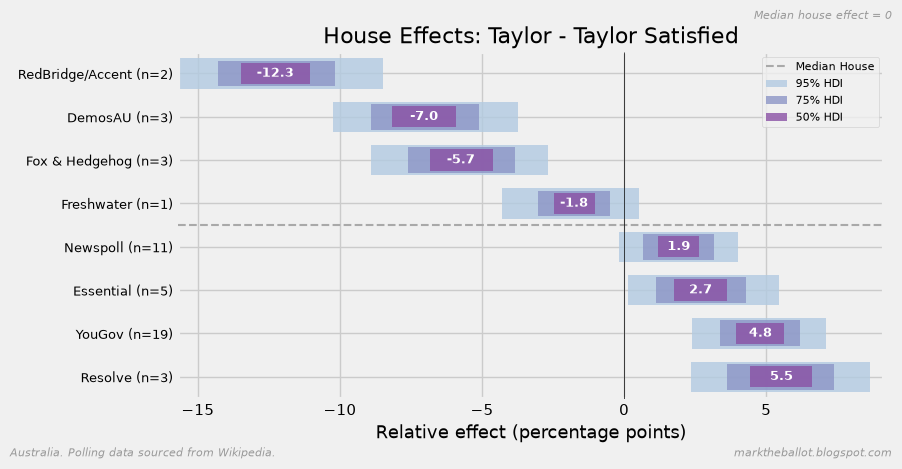


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 2.01
Minimum polls required: 5

Newspoll (n=11)
  Outside ±3σ: 0/11 (0.0%)
  Heteroskedasticity p-value: 0.498 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.43 (t-test p=0.645)

YouGov (n=19) ⚠️ SUSPECT
  Outside ±3σ: 1/19 (5.3%)
  Heteroskedasticity p-value: 0.025 (variance decreasing)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -2.07 (t-test p=0.047)

Essential (n=5) ⚠️ SUSPECT
  Outside ±3σ: 0/5 (0.0%)
  Heteroskedasticity p-value: 0.576 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +3.62 (t-test p=0.025)

⚠️  2 pollster(s) flagged for potential methodology issues:
   - YouGov
   - Essential


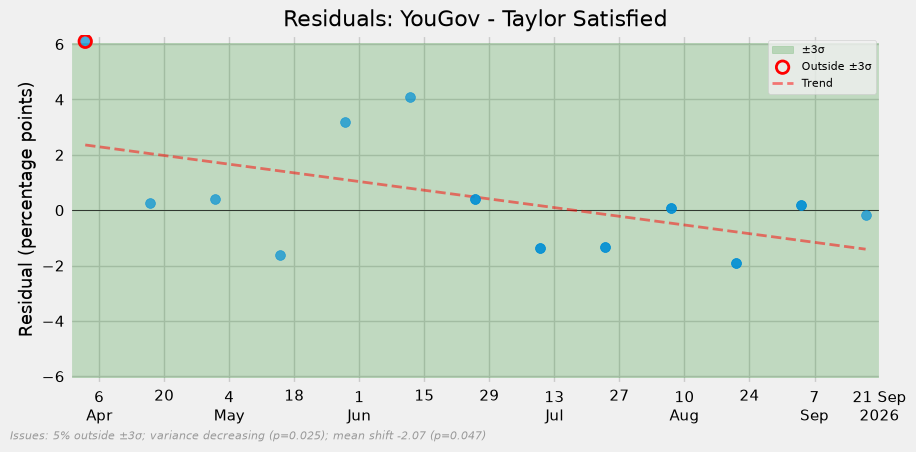

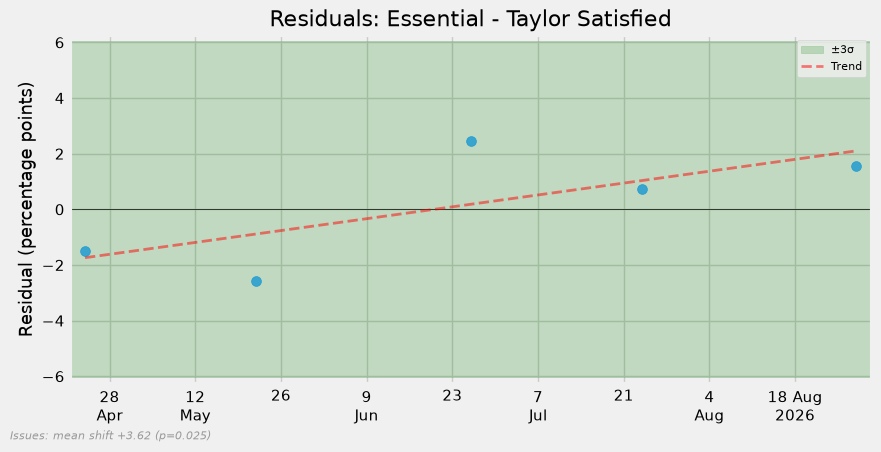

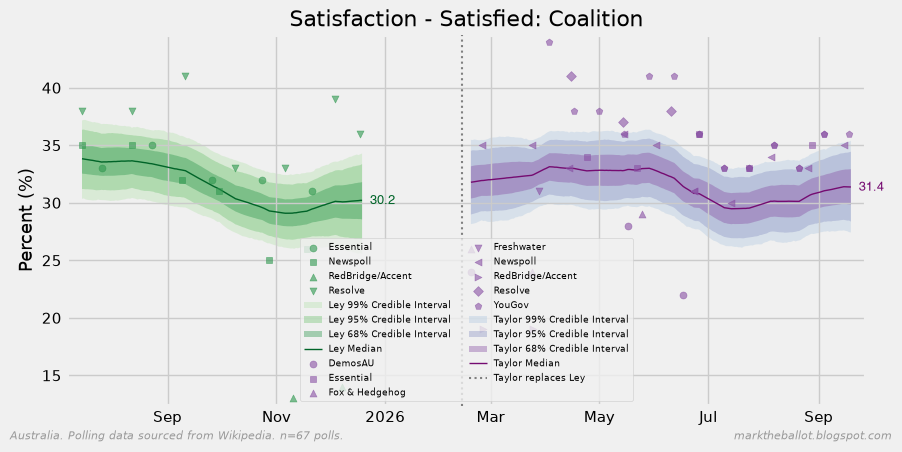

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Albanese Dissatisfied
Polls: 82
Pollsters: ['YouGov', 'Newspoll', 'Essential', 'Resolve', 'DemosAU', 'RedBridge/Accent', 'Fox & Hedgehog', 'Morning Consult', 'Freshwater']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 1200
Maximum MCSE/sd ratio: 0.031
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (11): 0.73% (comparing to observed max)
Minimum BFMI: 0.97
Completed: Albanese Dissatisfied


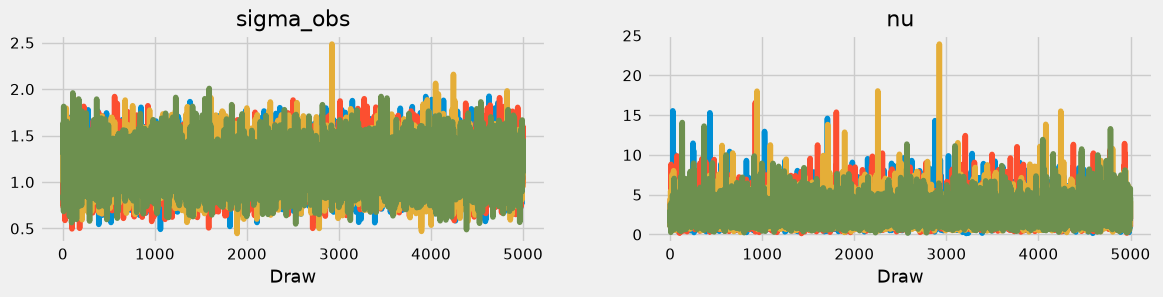

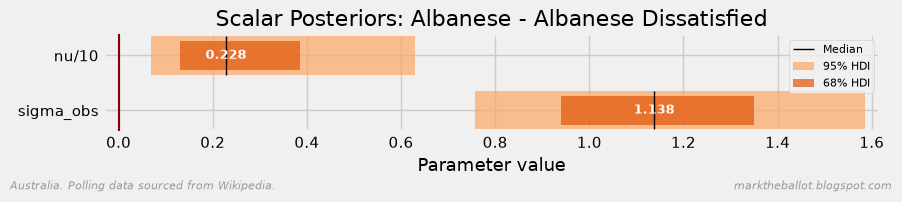

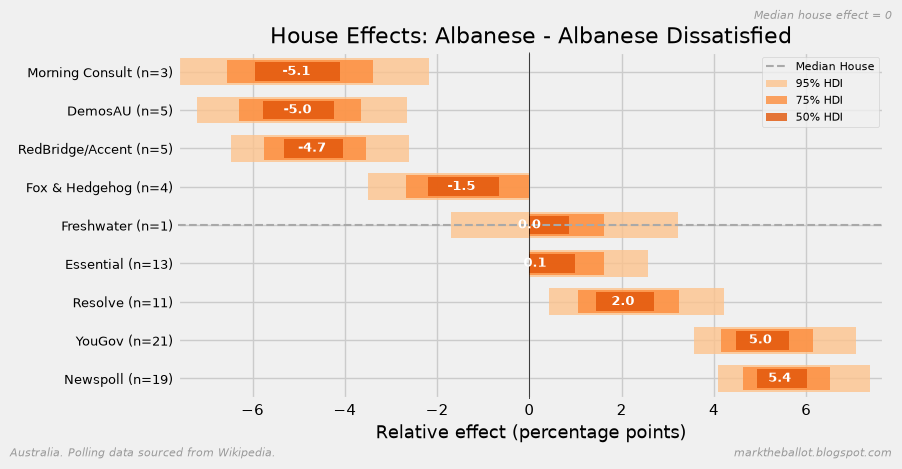


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.15
Minimum polls required: 5

Essential (n=13) ⚠️ SUSPECT
  Outside ±3σ: 1/13 (7.7%)
  Heteroskedasticity p-value: 0.814 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.31 (t-test p=0.693)

Resolve (n=11) ⚠️ SUSPECT
  Outside ±3σ: 1/11 (9.1%)
  Heteroskedasticity p-value: 0.722 (homoskedastic)
  Recent outliers: 1@3σ, 1@2σ (of 5)
  Mean shift: +1.06 (t-test p=0.433)

Newspoll (n=19) ⚠️ SUSPECT
  Outside ±3σ: 0/19 (0.0%)
  Heteroskedasticity p-value: 0.026 (variance decreasing)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.50 (t-test p=0.292)

RedBridge/Accent (n=5)
  Outside ±3σ: 0/5 (0.0%)
  Heteroskedasticity p-value: 0.204 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.21 (t-test p=0.840)

DemosAU (n=5) ⚠️ SUSPECT
  Outside ±3σ: 0/5 (0.0%)
  Heteroskedasticity p-value: 0.243 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +2.64 (t-test p=0.040)

YouGov

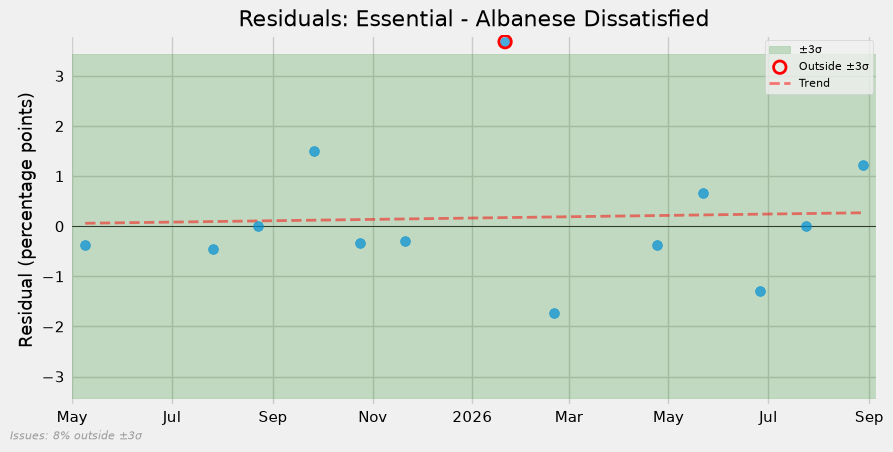

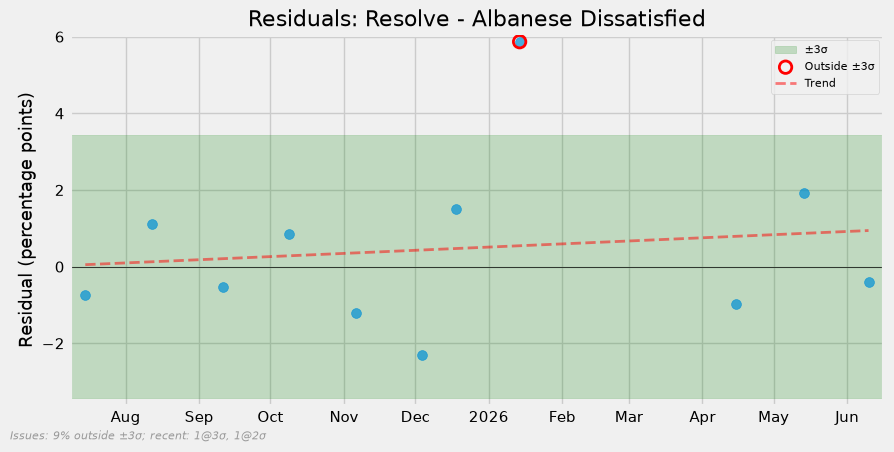

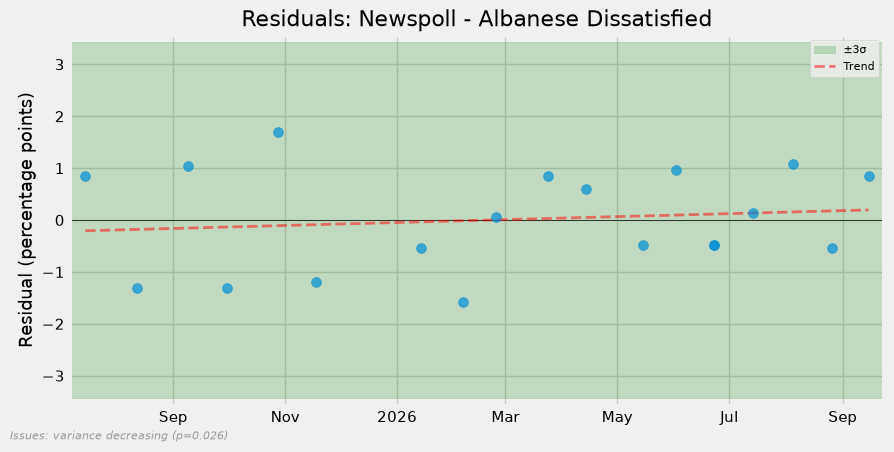

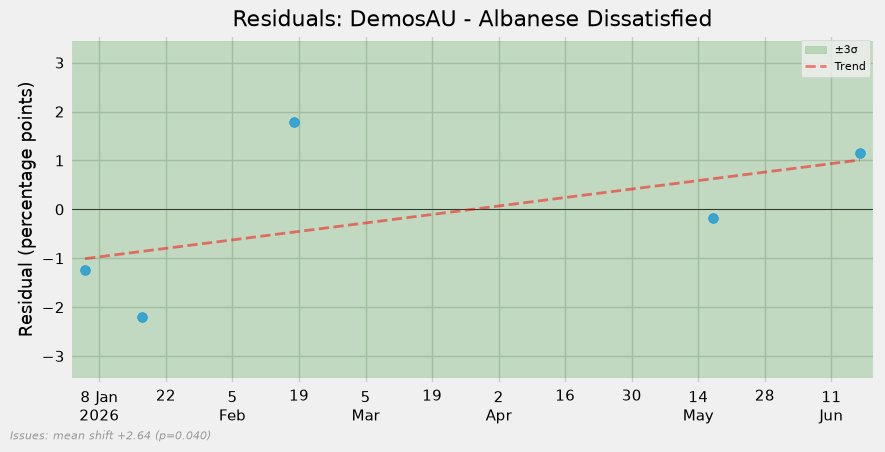

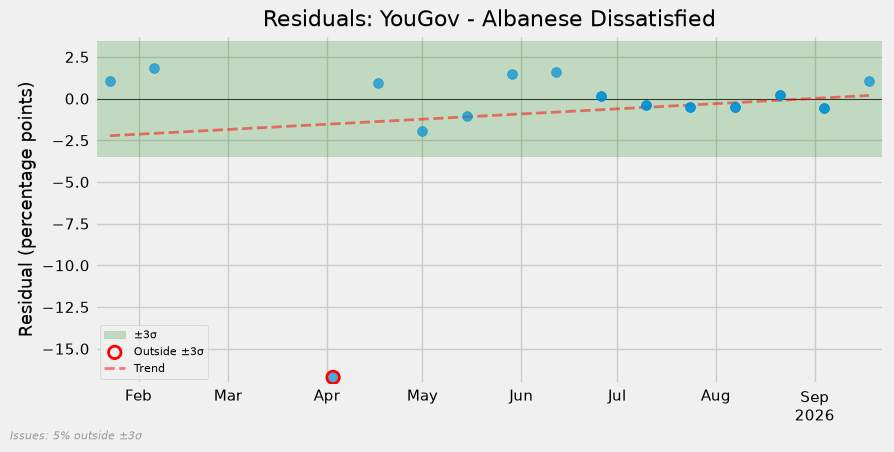

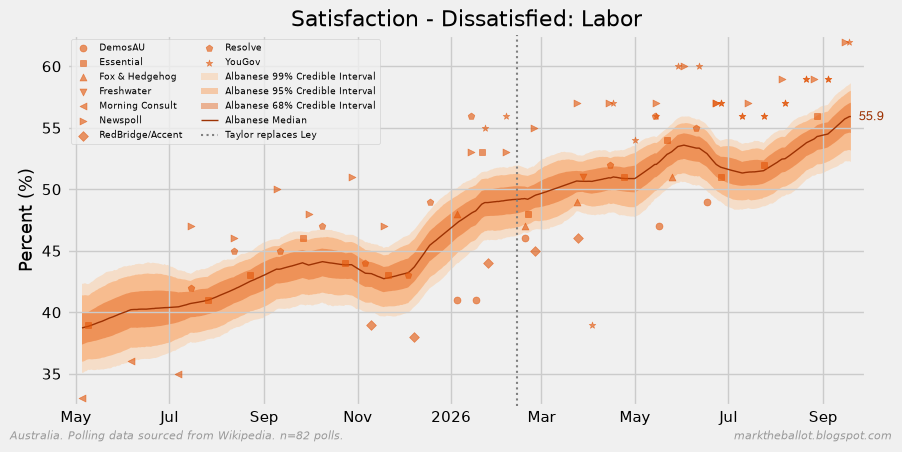

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Ley Dissatisfied
Polls: 20
Pollsters: ['Resolve', 'Newspoll', 'Essential', 'RedBridge/Accent']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 5400
Maximum MCSE/sd ratio: 0.015
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (10): 0.03% (comparing to observed max)
Minimum BFMI: 0.94
Completed: Ley Dissatisfied


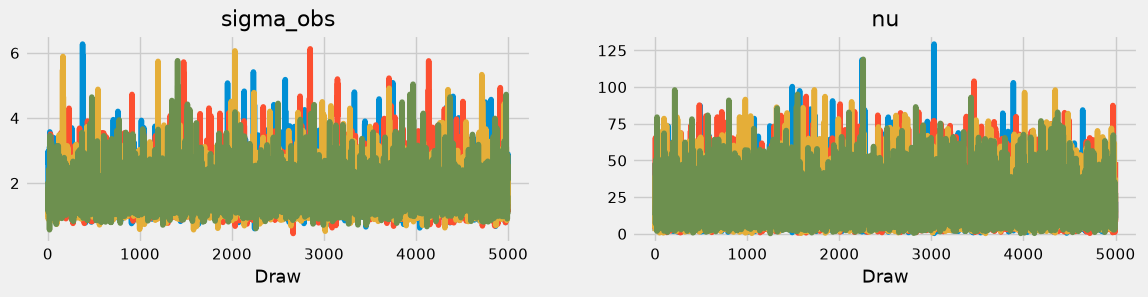

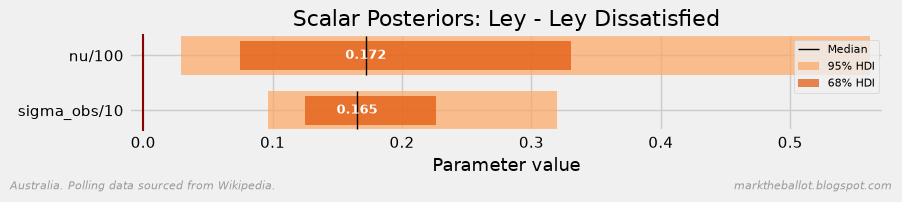

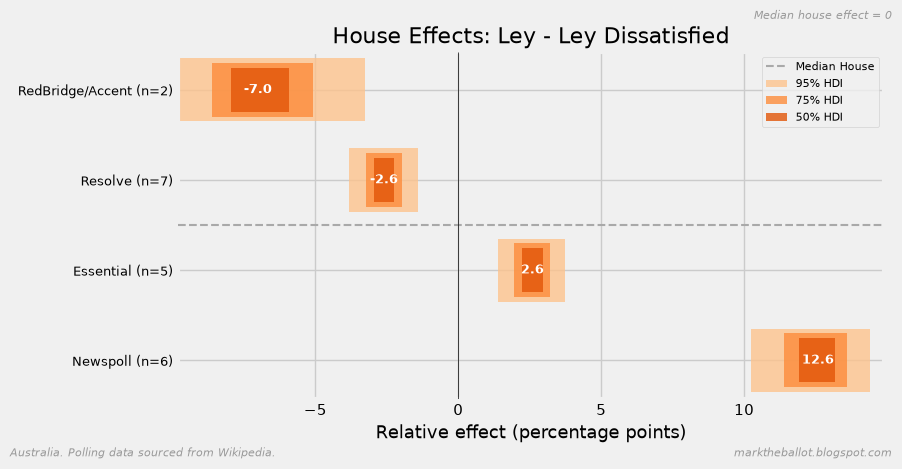

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.76
Minimum polls required: 5

Resolve (n=7)
  Outside ±3σ: 0/7 (0.0%)
  Heteroskedasticity p-value: 0.403 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +1.58 (t-test p=0.121)

Newspoll (n=6)
  Outside ±3σ: 0/6 (0.0%)
  Heteroskedasticity p-value: 0.777 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +2.95 (t-test p=0.094)

Essential (n=5)
  Outside ±3σ: 0/5 (0.0%)
  Heteroskedasticity p-value: 0.564 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.33 (t-test p=0.339)

✓ No pollsters flagged for methodology concerns.

Processing: Taylor Dissatisfied
Polls: 47
Pollsters: ['YouGov', 'Newspoll', 'Essential', 'Resolve', 'DemosAU', 'Fox & Hedgehog', 'RedBridge/Accent', 'Freshwater']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 2700
Maximum MCSE/sd ratio: 0.019
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (10): 1.71% (comparing to observed max)
Minimum BFMI: 0.96
Completed: Taylor Dissatisfied


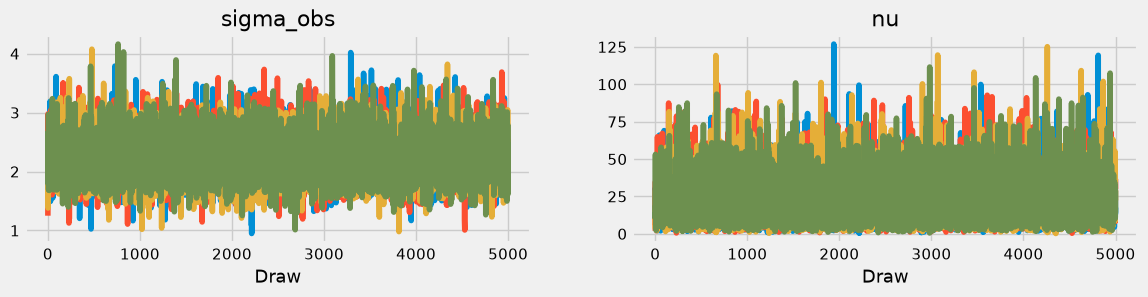

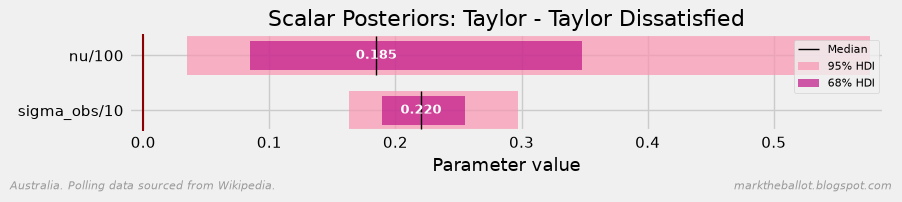

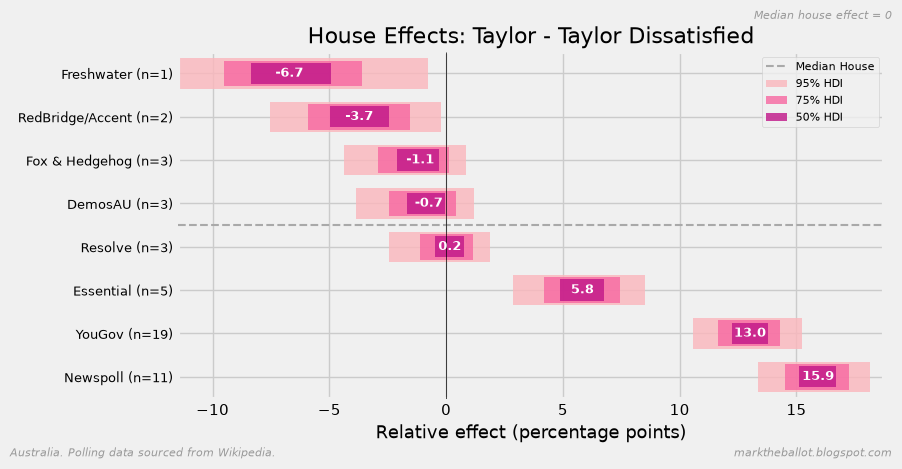


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 2.23
Minimum polls required: 5

Newspoll (n=11)
  Outside ±3σ: 0/11 (0.0%)
  Heteroskedasticity p-value: 0.598 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.22 (t-test p=0.882)

YouGov (n=19)
  Outside ±3σ: 0/19 (0.0%)
  Heteroskedasticity p-value: 0.087 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +1.33 (t-test p=0.178)

Essential (n=5)
  Outside ±3σ: 0/5 (0.0%)
  Heteroskedasticity p-value: 0.216 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.97 (t-test p=0.656)

✓ No pollsters flagged for methodology concerns.


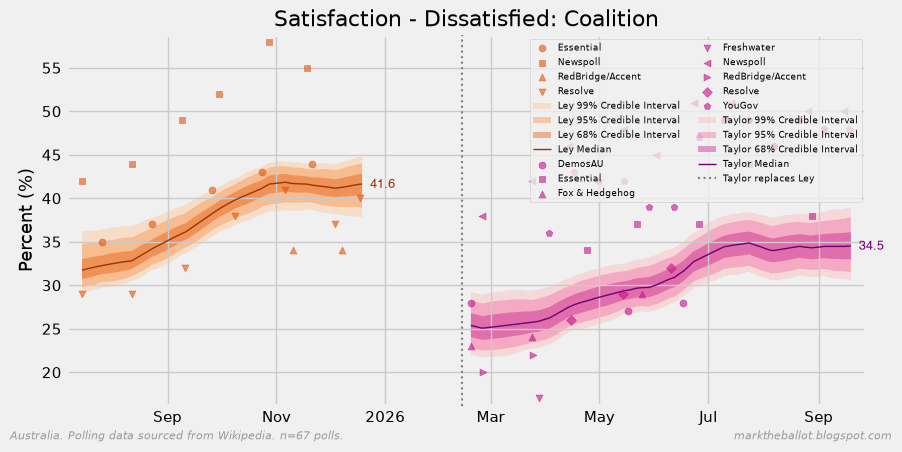

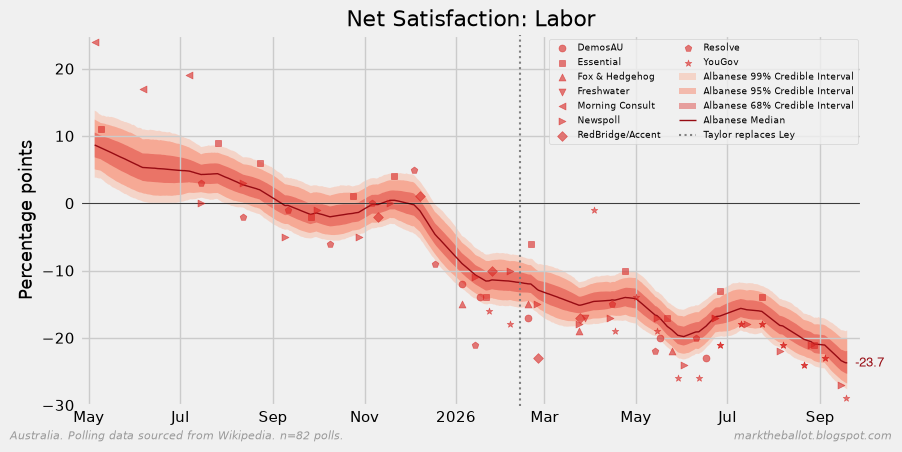

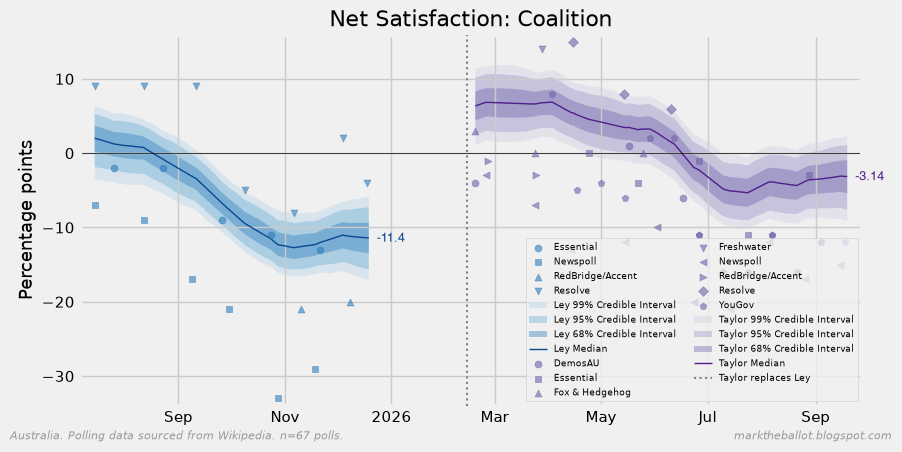

In [11]:
# Run models and plot timeseries, organised by measure then party.
# Higher innovation (0.3) than voting intention (0.1) because attitudinal
# data is sparser and more volatile.
INNOVATION = 0.3
from collections import defaultdict

# Results keyed by (leader, measure_type) e.g. ("Albanese", "ppm")
results = {}

# Build party -> [era] mapping
eras_by_party = defaultdict(list)
for era in LEADER_ERAS:
    eras_by_party[era.party].append(era)

MEASURE_TYPES = ["ppm", "satisfied", "dissatisfied"]
MEASURE_TITLES = {
    "ppm": "Preferred Prime Minister",
    "satisfied": "Satisfaction - Satisfied",
    "dissatisfied": "Satisfaction - Dissatisfied",
}


for measure_type in MEASURE_TYPES:
    for party, eras in eras_by_party.items():
        ts_data = []  # collected timeseries data for phase 2

        # Phase 1: run models and plot per-era diagnostics
        for era in eras:
            column = columns_for_era(era)[measure_type]
            if column not in df.columns:
                print(f"Skipping {column} - not in data")
                continue

            df_model = filter_df_to_era(df, era)

            # For PPM only: exclude 3-way rows (e.g. Hanson)
            if measure_type == "ppm":
                df_model = df_model[~df_model["_ppm_3way"]].copy()

            result = run_grw_for_column(df_model, column, innovation=INNOVATION)

            if result is None:
                continue

            key = (era.leader, measure_type)
            results[key] = {**result, "era": era}
            inputs = result["inputs"]
            idata = result["idata"]
            constraint = result["constraint"]
            poll_counts = result["poll_counts"]
            palette = palette_for(era, measure_type)

            plot_posteriors_bar(
                idata,
                series_name=f"{era.leader} - {column}",
                rfooter=RFOOTER,
                lfooter=LFOOTER,
                palette=palette,
                show=SHOW,
            )

            if constraint == "zero_median":
                rheader = "Median house effect = 0"
            else:
                he_sum_inclusions = inputs["he_sum_inclusions"]
                rheader = f"Sum to zero: {', '.join(he_sum_inclusions)}"
            plot_house_effects_bar(
                idata,
                inputs["back_firm_map"],
                model_name=f"{era.leader} - {column}",
                poll_counts=poll_counts,
                palette=palette,
                rheader=rheader,
                rfooter=RFOOTER,
                lfooter=LFOOTER,
                show=SHOW,
            )

            check_residuals(inputs, idata, verbose=True, show=SHOW)

            # Collect timeseries data
            vi_samples = get_vector_var("voting_intention", idata)
            vi_samples = vi_samples - inputs["centre_offset"]
            date_index = pd.period_range(
                inputs["day_zero"], periods=len(vi_samples), freq="D"
            )
            vi_samples.index = date_index

            df_plot = df_model[df_model[column].replace(0, np.nan).notna()].copy()
            df_plot.index = pd.PeriodIndex(df_plot[MIDDLE_DATE], freq="D")

            ts_data.append(
                {
                    "vi_samples": vi_samples,
                    "df_plot": df_plot,
                    "column": column,
                    "palette": palette,
                    "legend_stem": era.leader,
                }
            )

        # Phase 2: build combined timeseries chart from collected data
        if not ts_data:
            continue

        _, ax = plt.subplots(figsize=(12, 6))
        n_total = 0
        for td in ts_data:
            n_total += len(td["df_plot"])
            ax = plot_posterior_timeseries(
                data=td["vi_samples"],
                poll_data=td["df_plot"],
                poll_column=td["column"],
                legend_stem=td["legend_stem"],
                palette=td["palette"],
                ax=ax,
                finalise=False,
            )
        _add_transition_lines(ax)
        mg.finalise_plot(
            ax,
            title=f"{MEASURE_TITLES[measure_type]}: {party}",
            ylabel="Percent (%)",
            legend={"loc": "best", "fontsize": "xx-small", "ncol": 2},
            rfooter=RFOOTER,
            lfooter=f"{LFOOTER}n={n_total} polls.",
            show=SHOW,
        )


# --- Net Satisfaction: one chart per party, derived from posteriors ---
def _prepare_era_samples(
    era: LeaderEra, measure_type: str
) -> tuple[pd.DataFrame, pd.DataFrame, str, str]:
    """Prepare samples and poll data for an era/measure."""
    key = (era.leader, measure_type)
    result = results[key]
    inputs = result["inputs"]
    idata = result["idata"]
    column = columns_for_era(era)[measure_type]

    vi_samples = get_vector_var("voting_intention", idata)
    vi_samples = vi_samples - inputs["centre_offset"]
    date_index = pd.period_range(inputs["day_zero"], periods=len(vi_samples), freq="D")
    vi_samples.index = date_index

    df_era_plot = filter_df_to_era(df, era)
    df_plot = df_era_plot[df_era_plot[column].replace(0, np.nan).notna()].copy()
    df_plot.index = pd.PeriodIndex(df_plot[MIDDLE_DATE], freq="D")

    palette = palette_for(era, measure_type)
    return vi_samples, df_plot, column, palette


def _get_net_era_data(
    era: LeaderEra,
) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    """Compute net satisfaction samples and poll data for a leader era."""
    sat_samples, _, _, _ = _prepare_era_samples(era, "satisfied")
    dis_samples, _, _, _ = _prepare_era_samples(era, "dissatisfied")

    common_idx = sat_samples.index.intersection(dis_samples.index)
    net_samples = sat_samples.loc[common_idx] - dis_samples.loc[common_idx]

    sat_col = columns_for_era(era)["satisfied"]
    dis_col = columns_for_era(era)["dissatisfied"]
    df_era_plot = filter_df_to_era(df, era).copy()
    both_mask = df_era_plot[sat_col].notna() & df_era_plot[dis_col].notna()
    df_net = df_era_plot[both_mask].copy()
    net_col = f"{era.leader} Net Satisfaction"
    df_net[net_col] = pd.to_numeric(df_net[sat_col], errors="coerce") - pd.to_numeric(
        df_net[dis_col], errors="coerce"
    )
    df_net = df_net[df_net[net_col].notna()].copy()
    df_net.index = pd.PeriodIndex(df_net[MIDDLE_DATE], freq="D")
    return net_samples, df_net, net_col


def _plot_comparison(
    eras: list[LeaderEra],
    get_data_fn,
    title: str,
    ylabel: str,
    *,
    zero_line: bool = False,
    ncol: int = 3,
    n_polls: int | None = None,
) -> None:
    """Plot a combined comparison chart for multiple leader eras."""
    _, ax = plt.subplots(figsize=(12, 6))
    n_total = 0
    for era in eras:
        samples, df_plot, col, palette = get_data_fn(era)
        n_total += len(df_plot) if df_plot is not None else 0
        ax = plot_posterior_timeseries(
            data=samples,
            poll_data=df_plot,
            poll_column=col,
            legend_stem=era.leader,
            palette=palette,
            ax=ax,
            finalise=False,
        )
    if zero_line:
        ax.axhline(0, color="black", linestyle="-", linewidth=0.5, zorder=2)
    _add_transition_lines(ax)
    if n_polls is not None:
        n_total = n_polls
    mg.finalise_plot(
        ax,
        title=title,
        ylabel=ylabel,
        legend={"loc": "best", "fontsize": "xx-small", "ncol": ncol},
        rfooter=RFOOTER,
        lfooter=f"{LFOOTER}n={n_total} polls.",
        show=SHOW,
    )


net_by_party = defaultdict(list)
for era in LEADER_ERAS:
    if (era.leader, "satisfied") in results and (era.leader, "dissatisfied") in results:
        net_by_party[era.party].append(era)

for party, eras in net_by_party.items():
    _plot_comparison(
        eras,
        lambda era: (*_get_net_era_data(era), era.ppm_palette),
        title=f"Net Satisfaction: {party}",
        ylabel="Percentage points",
        zero_line=True,
        ncol=2,
    )

## Comparison Charts

Combined charts showing model estimates without individual poll markers.

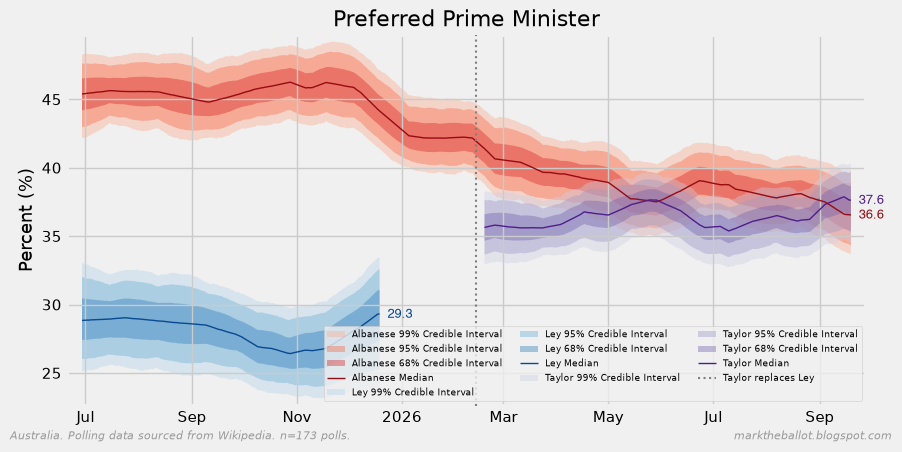

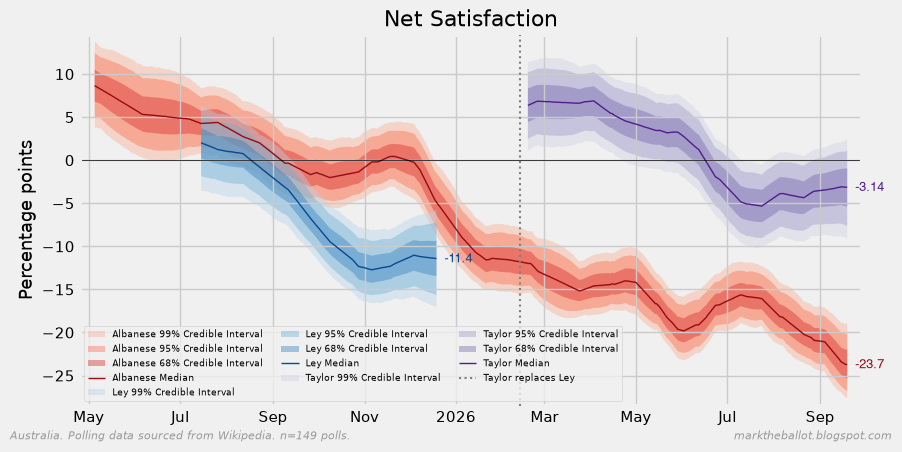

In [12]:
# --- Preferred Prime Minister: all parties on one chart (no poll markers) ---
ppm_eras = [era for era in LEADER_ERAS if (era.leader, "ppm") in results]
n_ppm = sum(
    len(_prepare_era_samples(era, "ppm")[1]) for era in ppm_eras
)


def _ppm_comparison_data(era):
    vi_samples, _, _, palette = _prepare_era_samples(era, "ppm")
    return vi_samples, None, None, palette


_plot_comparison(
    ppm_eras,
    _ppm_comparison_data,
    title="Preferred Prime Minister",
    ylabel="Percent (%)",
    n_polls=n_ppm,
)

# --- Net Satisfaction: all parties on one chart (no poll markers) ---
net_eras = [
    era
    for era in LEADER_ERAS
    if (era.leader, "satisfied") in results and (era.leader, "dissatisfied") in results
]
n_net = sum(len(_get_net_era_data(era)[1]) for era in net_eras)


def _net_comparison_data(era):
    net_samples, _, _ = _get_net_era_data(era)
    return net_samples, None, None, era.ppm_palette


_plot_comparison(
    net_eras,
    _net_comparison_data,
    title="Net Satisfaction",
    ylabel="Percentage points",
    zero_line=True,
    n_polls=n_net,
)

## Finished

In [13]:
%load_ext watermark
%watermark -t -d -u --python --machine --conda --iversions --watermark

Last updated: 2026-09-23 13:36:14

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.17.1

conda environment: n/a

Compiler    : Clang 21.1.4 
OS          : Darwin
Release     : 27.0.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

matplotlib: 3.11.2
mgplot    : 0.2.33
numpy     : 2.5.3
pandas    : 3.0.6

Watermark: 2.6.0

